# DD paper — behavioural figure code

Everything behavioural for the paper lives here. The figure itself is assembled by hand in
Affinity from the panel PDFs this notebook exports, so each section produces a
**standalone, drop-in PDF** rather than one pre-assembled figure.

| section | exports | goes where |
|---|---|---|
| Panel B | `panelB_mag_behav_probit_control-dys.pdf` | Fig. 1B |
| Panel D | `panelD_mag_bauerv4_rdm_full_cont_control-dys.pdf` | Fig. 1D |
| Parameter matrix | `magjudge_param_matrix_*.pdf` | supplementary / results |

Panels B and D were previously `panelB_standalone.py` / `panelD_standalone.py` in this
folder; they are folded in here so all the behavioural code sits in one place. The old
full-figure assembly that used to be in this notebook is gone — it was abandoned in favour
of the Affinity layout.

Run with **`mambaforge/envs/behav_fit`**: `plot_group_comparison_panel` needs seaborn ≥
0.13 (`legend=` on barplot), and the matrix needs `pingouin`.

In [1]:
import os
import os.path as op
import sys

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import mannwhitneyu, normaltest, ttest_ind

sys.path.insert(0, '/Users/mrenke/git')
from parietal_patterns.prep_results.plotting import (
    set_style, format_pvalue, plot_group_comparison_panel,
    GROUP_LABELS, GROUP_ORDER, GROUP_PALETTE)
from parietal_patterns.utils.statistics import sig_stars

set_style()

BIDS = '/Users/mrenke/data/ds-dnumrisk'
COGMODELS = op.join(BIDS, 'derivatives', 'cogmodels_magjudge')
OUT_DIRS = ['/Users/mrenke/Desktop/DNumRisk/figures/paperFigs_DD_03',
            '/Users/mrenke/obsidian-wiki/dyscalc_paper_rework/figures/plots']
for d in OUT_DIRS:
    os.makedirs(d, exist_ok=True)

ALPHA = 0.05

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Panel B — raw behaviour + choice curves

Reworked from the original panel B: the two grey probit-posterior densities are dropped
(they only restated a number that now sits over the curve it belongs to), and the freed
space goes to raw behaviour as the bar+swarm idiom used in the neural figures.

    row 1   accuracy, reaction time   -- plot_group_comparison_panel (bar + swarm + bracket)
    row 2   psychophysical curves, number-range interaction, each carrying the
            corresponding probit group-interaction p_bayes as a subtitle

number of subjects found: 66


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


number of subjects in dataframe: 66
Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54,
       55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66],
      dtype='int64', name='subject')


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 12.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 15.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
1 

panel B written


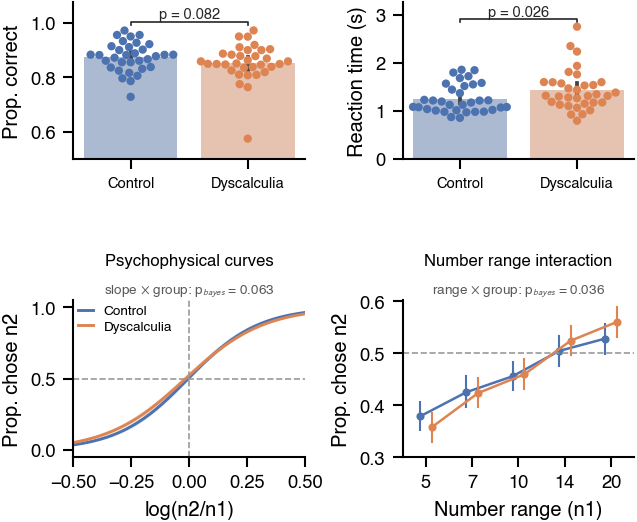

In [2]:
N_BOOT = 1000  # bootstrap reps for the logistic-fit CI band

from numrisk.behavior_magjudge.utils import get_data

trials = get_data(BIDS, include_var=['group']).sort_index()
trials['group_label'] = trials['group'].map(GROUP_LABELS)
trials['n1'] = trials['n1'].astype(int)
trials['x'] = trials['log(n2/n1)']

# subject-wise accuracy and RT (same derivation as numrisk paper_dnumrisk_01.ipynb cell 4)
trials['correct'] = (trials['n2'] > trials['n1']) == trials['chose_n2']
subj = trials.groupby(['subject', 'group_label'])[['correct', 'rt']].mean().reset_index()

probit = az.from_netcdf(op.join(COGMODELS, 'probit_model-2_trace.netcdf'))


# directional a-priori hypothesis per measure, phrased as the alternative for
# (control vs dyscalculia): controls more accurate, controls faster. We never
# expected dyscalculics to be better or faster, so these are tested one-sided.
ALTERNATIVE = {'correct': 'greater', 'rt': 'less'}


def group_stat(measure):
    """t-test or Mann-Whitney depending on normality -- the rule already used for these
    two measures in numrisk paper_dnumrisk_01.ipynb, kept so the numbers don't move.

    One-sided in the direction of ALTERNATIVE[measure]: the hypothesis is that
    dyscalculics are less accurate and slower, and the opposite direction was
    neither expected nor of interest."""
    ctrl = subj.loc[subj['group_label'] == 'Control', measure]
    dys = subj.loc[subj['group_label'] == 'Dyscalculia', measure]
    _, p_normal = normaltest(subj[measure].dropna())
    if p_normal > ALPHA:
        return ttest_ind(ctrl, dys, alternative=ALTERNATIVE[measure])
    return mannwhitneyu(ctrl, dys, alternative=ALTERNATIVE[measure])


def probit_p(regressor):
    """Smaller posterior tail of a probit group-interaction term."""
    samples = probit.posterior[regressor].to_dataframe()[regressor]
    above = float(np.mean(samples > 0))
    return min(above, 1 - above)


def subtitle(ax, name, note):
    """Panel name + a lighter p-value line -- same two-text arrangement as panel D, so the
    gap between them stays tunable independently of title line spacing."""
    ax.set_title(name, fontsize=8, pad=17)
    ax.text(0.5, 1.01, note, transform=ax.transAxes, ha='center', va='bottom',
            fontsize=6.5, color='0.35')


def panel_B():
    fig, axes = plt.subplots(2, 2, figsize=(4.35, 3.7))
    (ax_acc, ax_rt), (ax_curve, ax_range) = axes
    fig.subplots_adjust(wspace=0.42, hspace=0.90, left=0.13, right=0.99,
                        top=0.93, bottom=0.11)

    # row 1: raw behaviour, house bar+swarm idiom
    plot_group_comparison_panel(ax_acc, subj, 'correct', 'Prop. correct',
                                group_stat('correct'), ymin=0.5)
    plot_group_comparison_panel(ax_rt, subj, 'rt', 'Reaction time (s)', group_stat('rt'))
    for ax in (ax_acc, ax_rt):
        ax.tick_params(axis='x', labelsize=7)

    # row 2: choice curves, each carrying its probit interaction p_bayes
    for label in GROUP_ORDER:
        sub = trials[trials['group_label'] == label]
        sns.regplot(data=sub, x='x', y='chose_n2', logistic=True, scatter=False,
                    ci=95, n_boot=N_BOOT, color=GROUP_PALETTE[label],
                    line_kws={'linewidth': 1.4}, ax=ax_curve)
    ax_curve.axvline(0, color='0.6', ls='--', lw=0.8)
    ax_curve.axhline(0.5, color='0.6', ls='--', lw=0.8)
    ax_curve.set_xlim(-0.5, 0.5)
    ax_curve.set_yticks([0, 0.5, 1])
    ax_curve.set_xlabel('log(n2/n1)')
    ax_curve.set_ylabel('Prop. chose n2')
    handles = [plt.Line2D([], [], color=GROUP_PALETTE[g], lw=1.4, label=g)
               for g in GROUP_ORDER]
    ax_curve.legend(handles=handles, loc='upper left', fontsize=6.5, handlelength=1.1,
                    borderpad=0.15, labelspacing=0.2, borderaxespad=0.2)
    subtitle(ax_curve, 'Psychophysical curves',
             f'slope $\\times$ group: {format_pvalue(probit_p("x:group"), "p$_{bayes}$")}')
    sns.despine(ax=ax_curve)

    sns.pointplot(data=trials.reset_index(), x='n1', y='chose_n2', hue='group_label',
                  hue_order=GROUP_ORDER, palette=GROUP_PALETTE, dodge=0.25,
                  errorbar=('ci', 95), markersize=3, linewidth=1.2,
                  err_kws={'linewidth': 1.0}, ax=ax_range)
    ax_range.axhline(0.5, color='0.6', ls='--', lw=0.8)
    ax_range.set_yticks([0.3, 0.4, 0.5, 0.6])
    ax_range.set_xlabel('Number range (n1)')
    ax_range.set_ylabel('Prop. chose n2')
    ax_range.legend_.remove()  # shared with the curve panel
    subtitle(ax_range, 'Number range interaction',
             f'range $\\times$ group: {format_pvalue(probit_p("n1:group"), "p$_{bayes}$")}')
    sns.despine(ax=ax_range)
    return fig


fig_b = panel_B()
for d in OUT_DIRS:
    fig_b.savefig(op.join(d, 'panelB_mag_behav_probit_control-dys.pdf'))
print('panel B written')

## Panel D — PMC-RDM group posteriors

Posterior densities of the `rdm_full_cont` parameters per group, with the two-sided
posterior tail probability of the group difference over each.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


panel D written


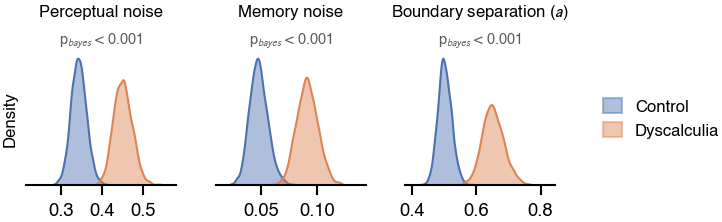

In [3]:
rdm = az.from_netcdf(op.join(COGMODELS, 'model-rdm_full_cont_hn_trace.nc'))


def softplus(x):
    """bauer.utils.bayes.softplus, inlined (importing it pulls in pytensor)."""
    return np.log(1 + np.exp(-np.abs(x))) + np.maximum(x, 0)


def panel_D():
    params = ['perceptual_noise_sd', 'memory_noise_sd', 'a']
    names = ['Perceptual noise', 'Memory noise', 'Boundary separation ($a$)']

    # 3 params + a legend column on the right, matching where the legend sat in the
    # old panel D so it drops into the same slot in the Affinity document
    fig, axes = plt.subplots(1, 4, figsize=(5.6, 1.15),
                             gridspec_kw={'width_ratios': [1, 1, 1, 0.55], 'wspace': 0.3})
    ax_leg = axes[3]

    for ax, param, name in zip(axes[:3], params, names):
        tmp = (rdm.posterior[f'{param}_mu'].to_dataframe()[f'{param}_mu']
               .unstack(f'{param}_regressors'))
        by_group = {'Control': softplus(tmp['C(group)[control]']),
                    'Dyscalculia': softplus(tmp['C(group)[dyscalc]'])}
        # two-sided posterior tail probability of the group difference
        below = float(np.mean((by_group['Dyscalculia'] - by_group['Control']) < 0))
        p = below if below < 0.5 else 1 - below

        for label in GROUP_ORDER:
            sns.kdeplot(x=by_group[label], color=GROUP_PALETTE[label], fill=True,
                        lw=1.0, alpha=0.45, legend=False, ax=ax)
        ax.set(yticks=[], xlabel='')
        ax.set_ylabel('Density' if ax is axes[0] else '', fontsize=8)
        # title and p-value are separate texts rather than one two-line title, so the gap
        # between them (pad vs. the p-value's y) is tunable independently of line spacing
        ax.set_title(name, fontsize=8, pad=17)
        ax.text(0.5, 1.01, format_pvalue(p, 'p$_{bayes}$'), transform=ax.transAxes,
                ha='center', va='bottom', fontsize=7, color='0.35')
        ax.locator_params(axis='x', nbins=3)
        ax.margins(x=0.08)
        sns.despine(ax=ax, left=True, trim=False)

    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=GROUP_PALETTE[g], alpha=0.45,
                             edgecolor=GROUP_PALETTE[g], lw=1.0, label=g)
               for g in GROUP_ORDER]
    ax_leg.legend(handles=handles, loc='center left', handlelength=1.1,
                  handleheight=1.0, borderpad=0.0, labelspacing=0.5, fontsize=8)
    ax_leg.axis('off')
    return fig


fig_d = panel_D()
for d in OUT_DIRS:
    fig_d.savefig(op.join(d, 'panelD_mag_bauerv4_rdm_full_cont_control-dys.pdf'))
print('panel D written')

## How the magnitude-comparison parameters relate to each other

The same matrix idiom as Fig. 4 in `paperDD_combFig1.ipynb` — |ρ| shading with the signed
coefficient printed, stars for significance, group partialled out and FDR correction as
independent switches — but applied *within* the magnitude-comparison task rather than
across behaviour and brain.

Restricted to the task's own measures: raw accuracy and RT, the two probit parameters, the
two noise parameters from the **choice-only (PMC)** fit, and the five **PMC-RDM**
parameters. `w_0` — the race model's drift intercept — is fit but never made it into the
exported subject-level CSV, so it is read off the trace directly (see the code comment for
the transform, which cannot affect a rank correlation anyway). `t0` is kept here (unlike Fig. 4, which drops it) because the question here is
how the task parameters relate to *each other*, and non-decision time is one of them. The
two psychometric intercepts stay excluded, as in the thesis version.

Including both model variants makes the convergence between them visible instead of
assumed: the same noise parameter estimated from choices alone vs. from choices **and** RT
can be read off against each other, so how much the RT information moves the estimate is
directly visible. The choice-only rows sit at the bottom because they are a convergence
check rather than part of the reported model. Set `INCLUDE_PMC_ONLY = False` to drop them again — note that doing so also
shrinks the FDR family, so the other cells' corrected p-values will shift.

The matrix is symmetric, so only one triangle is drawn; the diagonal is hidden too, since
it is all 1.00 by construction and carries no information.

In [4]:
import itertools

from numrisk.behavior_general.measures_registry import (
    load_all, _load_magjudge_bauer, PHENOTYPE_DIR)

CONTROL_GROUP_VARIANCE = True        # partial out DD-vs-control from every pair
CORRECT_MULTIPLE_COMPARISONS = True  # stars from corrected p instead of raw p
MC_METHOD = 'fdr_bh'
SHOW_TRIANGLE = 'lower'              # 'lower' (as in the thesis figure) or 'upper'
INCLUDE_W0 = True                    # drift intercept, read off the trace (not in the CSV)
VMAX_M = 0.8                         # within-task pairs run much higher than cross-domain ones
INCLUDE_PMC_ONLY = True              # also show the choice-only model's two noise params

df_meas, col_to_category = load_all()

# Raw magjudge task performance (not in the measures registry)
raw_perf = (pd.read_csv(op.join(PHENOTYPE_DIR, 'magjudge_raw_correct_rt.csv'))
            .set_index('subject')
            .rename(columns={'correct': 'accuracy_magjudge', 'rt': 'rt_magjudge'}))
df_meas = df_meas.join(raw_perf, how='left')
col_to_category.update({c: 'behavioral_magjudge' for c in raw_perf.columns})

# The choice-only (PMC) fit estimates the same two noise parameters from choices alone,
# where the PMC-RDM fit also uses RT. load_all() already carries the RDM variant under the
# bare names, so the choice variant comes in suffixed to sit beside it rather than clash.
if INCLUDE_PMC_ONLY:
    df_meas = df_meas.join(_load_magjudge_bauer('v4_choice', suffix_columns=True), how='left')

# w_0 (the race model's drift intercept) is fit but was never exported to the subject-level
# CSV, so it comes straight off the trace loaded for panel D. Single 'Intercept' regressor,
# so unlike the noise/a/t0 columns there is no per-subject group column to select.
# Left untransformed, matching how the CSV stores the other two accumulator parameters
# (`a` and `t0` are raw there; only the noise SDs are softplus'd). The choice is cosmetic
# here regardless -- softplus is strictly increasing, so it cannot change a Spearman rho.
if INCLUDE_W0:
    df_meas['w_0'] = (rdm.posterior['w_0']
                      .mean(('chain', 'draw'))
                      .sel({'w_0_regressors': 'Intercept'})
                      .to_pandas())

df_meas['group_numeric'] = (df_meas['group'] == 'dyscalc').astype(int)

# explicit order: raw performance -> probit -> PMC-RDM, i.e. increasing model commitment
# The choice-only params go last rather than next to their PMC-RDM counterparts: they are
# a secondary convergence check, not part of the model actually reported, and the reader
# should meet the reported parameters first. In a lower triangle the trailing rows are
# also the widest, so every PMC-vs-everything comparison stays visible in one band.
mag_vars = (['accuracy_magjudge', 'rt_magjudge',
             'gamma_magjudge', 'n1_slope',
             'perceptual_noise_sd', 'memory_noise_sd', 'a']
            + (['w_0'] if INCLUDE_W0 else [])
            + ['t0']
            + (['perceptual_noise_sd_v4_choice', 'memory_noise_sd_v4_choice']
               if INCLUDE_PMC_ONLY else []))

# which model each measure comes from -- drives the block separators in the figure
MODEL_CLASS = {
    'accuracy_magjudge': 'Raw', 'rt_magjudge': 'Raw',
    'gamma_magjudge': 'Probit', 'n1_slope': 'Probit',
    'perceptual_noise_sd': 'PMC-RDM', 'memory_noise_sd': 'PMC-RDM',
    'a': 'PMC-RDM', 'w_0': 'PMC-RDM', 't0': 'PMC-RDM',
    'perceptual_noise_sd_v4_choice': 'PMC', 'memory_noise_sd_v4_choice': 'PMC',
}

pretty_mag = {
    'accuracy_magjudge': 'Raw: Accuracy',
    'rt_magjudge': 'Raw: Reaction time',
    'gamma_magjudge': r'Probit: slope ($\gamma$)',
    'n1_slope': 'Probit: number-range effect',
    'perceptual_noise_sd_v4_choice': 'PMC: Perceptual noise',
    'memory_noise_sd_v4_choice': 'PMC: Memory noise',
    'perceptual_noise_sd': 'PMC-RDM: Perceptual noise',
    'memory_noise_sd': 'PMC-RDM: Memory noise',
    'a': 'PMC-RDM: Boundary separation ($a$)',
    'w_0': 'PMC-RDM: Drift intercept ($w_0$)',
    't0': 'PMC-RDM: Non-decision time ($t_0$)',
}

corr_m = pd.DataFrame(np.nan, index=mag_vars, columns=mag_vars)
pval_m = pd.DataFrame(np.nan, index=mag_vars, columns=mag_vars)

for x_var, y_var in itertools.combinations(mag_vars, 2):
    sub = df_meas[[x_var, y_var, 'group_numeric']].dropna()
    if len(sub) < 10:
        continue
    if CONTROL_GROUP_VARIANCE:
        res = pingouin.partial_corr(data=sub, x=x_var, y=y_var, covar='group_numeric',
                                    method='spearman')
    else:
        res = pingouin.corr(sub[x_var], sub[y_var], method='spearman')
    r, p = res['r'].iloc[0], res['p-val'].iloc[0]
    corr_m.loc[x_var, y_var] = corr_m.loc[y_var, x_var] = r
    pval_m.loc[x_var, y_var] = pval_m.loc[y_var, x_var] = p

# Correct over the unique PAIRS, not over the filled matrix: every off-diagonal value
# appears twice by symmetry, and feeding both copies in would double the apparent number
# of tests and over-penalise every one of them.
pairs = list(itertools.combinations(mag_vars, 2))
p_flat = np.array([pval_m.loc[x, y] for x, y in pairs])
ok = ~np.isnan(p_flat)
p_corr_flat = np.full_like(p_flat, np.nan)
p_corr_flat[ok] = pingouin.multicomp(p_flat[ok], method=MC_METHOD)[1]

pval_m_corrected = pd.DataFrame(np.nan, index=mag_vars, columns=mag_vars)
for (x, y), pc in zip(pairs, p_corr_flat):
    pval_m_corrected.loc[x, y] = pval_m_corrected.loc[y, x] = pc

pval_m_shown = pval_m_corrected if CORRECT_MULTIPLE_COMPARISONS else pval_m
print(f'{int(ok.sum())} unique pairs | raw p<.05: {int((p_flat[ok] < .05).sum())}'
      f' | {MC_METHOD} p<.05: {int((p_corr_flat[ok] < .05).sum())}')

55 unique pairs | raw p<.05: 23 | fdr_bh p<.05: 21


### Shared matrix drawing

Both matrices in this notebook — the within-task one below and the cognitive x PMC-RDM one
further down — use the same conventions as Fig. 4, so the drawing lives in one function
rather than being written out twice and drifting apart.

In [5]:
CBAR_LABEL_M = (r'|partial Spearman $\rho$|' if CONTROL_GROUP_VARIANCE
                else r'|Spearman $\rho$|')
sequential_cmap = LinearSegmentedColormap.from_list('purple_seq', ['#f0efec', '#832ad6'])


def draw_matrix(ax, corr_df, pval_df, vmax, row_labels, col_labels,
                mask=None, cbar_label=None, cbar_shrink=0.5):
    """|rho| heatmap with signed annotations and significance stars.

    corr_df / pval_df must share row and column labels; `mask` (if given) hides cells and
    also suppresses their stars, so a masked triangle can't leak marks into empty space.
    """
    annot = corr_df.map(lambda v: '' if pd.isna(v) else f'{v:.2f}'.replace('-', '−'))
    sns.heatmap(corr_df.abs().astype(float), mask=mask, cmap=sequential_cmap,
                vmin=0, vmax=vmax, square=True, annot=annot.values, fmt='',
                annot_kws={'size': 8.5}, linewidths=0.5, linecolor='white',
                cbar_kws={'shrink': cbar_shrink, 'label': cbar_label, 'pad': 0.02}, ax=ax)

    ax.set_xticklabels(col_labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(row_labels, rotation=0, fontsize=8)
    ax.tick_params(length=0)

    # asterisks need a point size well above the numbers' to look comparable -- the glyph
    # sits high in its em box and fills little of it
    for i in range(corr_df.shape[0]):
        for j in range(corr_df.shape[1]):
            if mask is not None and mask[i, j]:
                continue
            stars = sig_stars(pval_df.iloc[i, j])
            if stars:
                ax.text(j + 0.5, i + 0.08, stars, ha='center', va='top',
                        fontsize=13, fontweight='bold', color='0.1')
    return ax

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


matrix written: magjudge_param_matrix_group-removed_fdr_bh.pdf


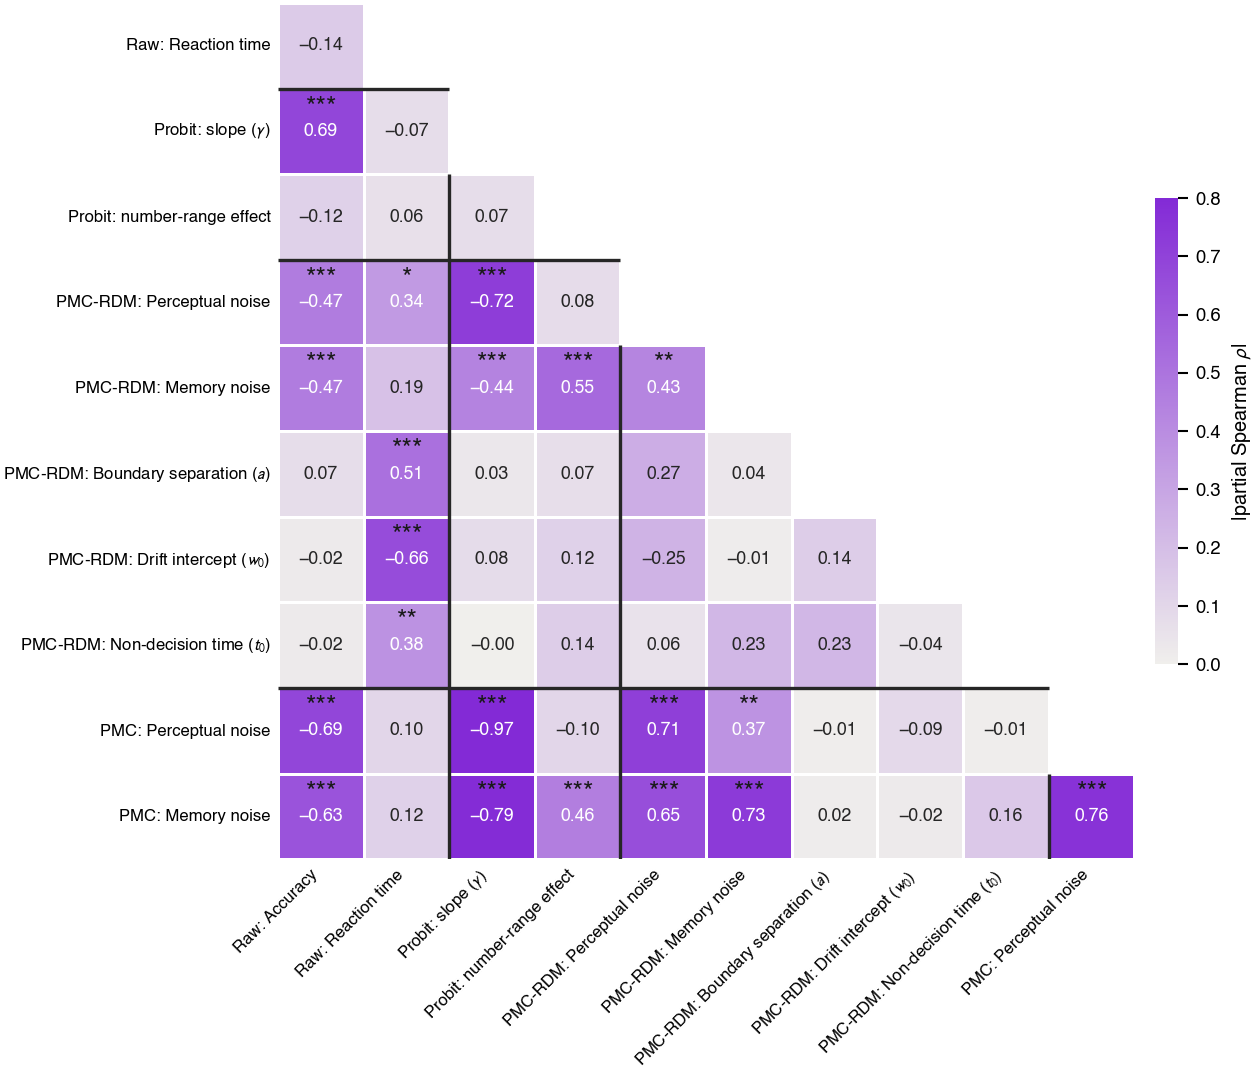

In [6]:
# The diagonal is dropped along with the redundant half: it is 1.00 everywhere by
# construction, so drawing it would spend the darkest colour on no information.
# Dropping it also empties one full row and one full column (the first variable never
# appears as a row in a lower triangle, the last never as a column), so those are trimmed
# off entirely rather than left as a blank band of axis labels.
if SHOW_TRIANGLE == 'lower':
    rows_m, cols_m = mag_vars[1:], mag_vars[:-1]
    mask_m = np.triu(np.ones((len(rows_m), len(cols_m)), dtype=bool), k=1)
else:
    rows_m, cols_m = mag_vars[:-1], mag_vars[1:]
    mask_m = np.tril(np.ones((len(rows_m), len(cols_m)), dtype=bool), k=-1)

fig_m, ax_m = plt.subplots(figsize=(0.62 * len(cols_m) + 2.8,
                                    0.62 * len(rows_m) + 1.6))
draw_matrix(ax_m, corr_m.loc[rows_m, cols_m], pval_m_shown.loc[rows_m, cols_m],
            vmax=VMAX_M, mask=mask_m, cbar_label=CBAR_LABEL_M,
            row_labels=[pretty_mag[c] for c in rows_m],
            col_labels=[pretty_mag[c] for c in cols_m])

# Thick separators between model classes. Positions are indices into the *untrimmed*
# mag_vars, then mapped into the trimmed grid: row i holds mag_vars[i+1], column j holds
# mag_vars[j], which is why the two get different offsets.
# Each line is clipped to the staircase edge instead of spanning the whole axes -- an
# axhline/axvline would run out across the masked half and read as a border around empty
# space rather than a division between blocks.
class_boundaries = [k for k in range(1, len(mag_vars))
                    if MODEL_CLASS[mag_vars[k]] != MODEL_CLASS[mag_vars[k - 1]]]
n_rows_m = len(rows_m)

for k in class_boundaries:
    if SHOW_TRIANGLE == 'lower':
        ax_m.plot([0, k], [k - 1, k - 1], color='0.15', lw=1.6,
                  solid_capstyle='butt', zorder=5)          # above the block break
        ax_m.plot([k, k], [k, n_rows_m], color='0.15', lw=1.6,
                  solid_capstyle='butt', zorder=5)          # left of the block break
    else:
        ax_m.plot([k - 1, len(cols_m)], [k - 1, k - 1], color='0.15', lw=1.6,
                  solid_capstyle='butt', zorder=5)
        ax_m.plot([k - 1, k - 1], [0, k - 1], color='0.15', lw=1.6,
                  solid_capstyle='butt', zorder=5)

fig_m.tight_layout()

suffix_m = ('_group-removed' if CONTROL_GROUP_VARIANCE else '') + \
           (f'_{MC_METHOD}' if CORRECT_MULTIPLE_COMPARISONS else '')
for d in OUT_DIRS:
    fig_m.savefig(op.join(d, f'magjudge_param_matrix{suffix_m}.pdf'))
print('matrix written:', f'magjudge_param_matrix{suffix_m}.pdf')

### The pairs, as a table

Sorted by raw p, with the corrected p alongside — for the results text.

In [7]:
rows = []
for x, y in pairs:
    rows.append({'measure A': pretty_mag[x], 'measure B': pretty_mag[y],
                 'rho': corr_m.loc[x, y], '|rho|': abs(corr_m.loc[x, y]),
                 'p_raw': pval_m.loc[x, y],
                 f'p_{MC_METHOD}': pval_m_corrected.loc[x, y]})

results_m = pd.DataFrame(rows).sort_values('p_raw').reset_index(drop=True)
results_m.round({'rho': 3, '|rho|': 3, 'p_raw': 4, f'p_{MC_METHOD}': 4})

,measure A,measure B,rho,|rho|,p_raw,p_fdr_bh
0,Probit: slope ($\gamma$),PMC: Perceptual noise,-0.967,0.967,0.0000,0.0000
1,Probit: slope ($\gamma$),PMC: Memory noise,-0.789,0.789,0.0000,0.0000
2,PMC: Perceptual noise,PMC: Memory noise,0.763,0.763,0.0000,0.0000
3,PMC-RDM: Memory noise,PMC: Memory noise,0.732,0.732,0.0000,0.0000
4,Probit: slope ($\gamma$),PMC-RDM: Perceptual noise,-0.719,0.719,0.0000,0.0000
5,PMC-RDM: Perceptual noise,PMC: Perceptual noise,0.714,0.714,0.0000,0.0000
6,Raw: Accuracy,Probit: slope ($\gamma$),0.687,0.687,0.0000,0.0000
7,Raw: Accuracy,PMC: Perceptual noise,-0.687,0.687,0.0000,0.0000
8,Raw: Reaction time,PMC-RDM: Drift intercept ($w_0$),-0.661,0.661,0.0000,0.0000
9,PMC-RDM: Perceptual noise,PMC: Memory noise,0.652,0.652,0.0000,0.0000


## Supplementary — standardized measures x PMC-RDM parameters

How the standardized cognitive measures relate to the parameters of the reported model.
Restricted to the three parameters that carry the theoretical claim: the two **noise**
terms (perceptual, memory) and the **caution** term (boundary separation *a*). `t0` is
left out here — non-decision time is a nuisance parameter, and including it would add a
column of null results plus five more tests to the correction family for no gain.

`mean_iq` is likewise left out: it is the average of `me` and `kn`, which are both rows
here already, so it would enter the family as a third, redundant test of the same thing.

Same conventions as everything else: partial Spearman with group removed, |rho| shading
with the signed coefficient printed, FDR over this matrix's own 15 tests. Note the family
is *this matrix*, independent of the within-task matrix above — they are separate
questions asked of separate figures, so pooling them would penalise both for a search
neither performed.

In [8]:
# rows ordered as the measures are introduced in the manuscript
cog_vars = ['skill_score', 'me', 'kn', 'erfassungsspanne', 'weber_transformed']
rdm_vars = ['perceptual_noise_sd', 'memory_noise_sd', 'a']

pretty_cog = {
    'skill_score': 'Math skill (DEMAT)',
    'me': 'Visuospatial IQ (Matrizen)',
    'kn': 'Verbal IQ (Kategorien nennen)',
    'erfassungsspanne': 'Visuospatial WM (Corsi span)',
    'weber_transformed': 'Weber fraction (log)',
}

corr_c = pd.DataFrame(np.nan, index=cog_vars, columns=rdm_vars)
pval_c = pd.DataFrame(np.nan, index=cog_vars, columns=rdm_vars)
n_c = pd.DataFrame(np.nan, index=cog_vars, columns=rdm_vars)

for cv in cog_vars:
    for rv in rdm_vars:
        sub = df_meas[[cv, rv, 'group_numeric']].dropna()
        if len(sub) < 10:
            continue
        if CONTROL_GROUP_VARIANCE:
            res = pingouin.partial_corr(data=sub, x=cv, y=rv, covar='group_numeric',
                                        method='spearman')
        else:
            res = pingouin.corr(sub[cv], sub[rv], method='spearman')
        corr_c.loc[cv, rv] = res['r'].iloc[0]
        pval_c.loc[cv, rv] = res['p-val'].iloc[0]
        n_c.loc[cv, rv] = len(sub)

# rectangular and with no symmetry, so every filled cell is its own test -- unlike the
# within-task matrix, the flattened array is already the right family
flat_c = pval_c.values.ravel()
ok_c = ~np.isnan(flat_c)
corr_flat_c = np.full_like(flat_c, np.nan)
corr_flat_c[ok_c] = pingouin.multicomp(flat_c[ok_c], method=MC_METHOD)[1]
pval_c_corrected = pd.DataFrame(corr_flat_c.reshape(pval_c.shape),
                                index=cog_vars, columns=rdm_vars)
pval_c_shown = pval_c_corrected if CORRECT_MULTIPLE_COMPARISONS else pval_c

print(f'{int(ok_c.sum())} tests | raw p<.05: {int((pval_c < .05).sum().sum())}'
      f' | {MC_METHOD} p<.05: {int((pval_c_corrected < .05).sum().sum())}')
print(f'n per cell: {int(n_c.min().min())}-{int(n_c.max().max())}')

15 tests | raw p<.05: 3 | fdr_bh p<.05: 1
n per cell: 66-66


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


written: cognitive_x_pmcrdm_matrix_group-removed_fdr_bh.pdf


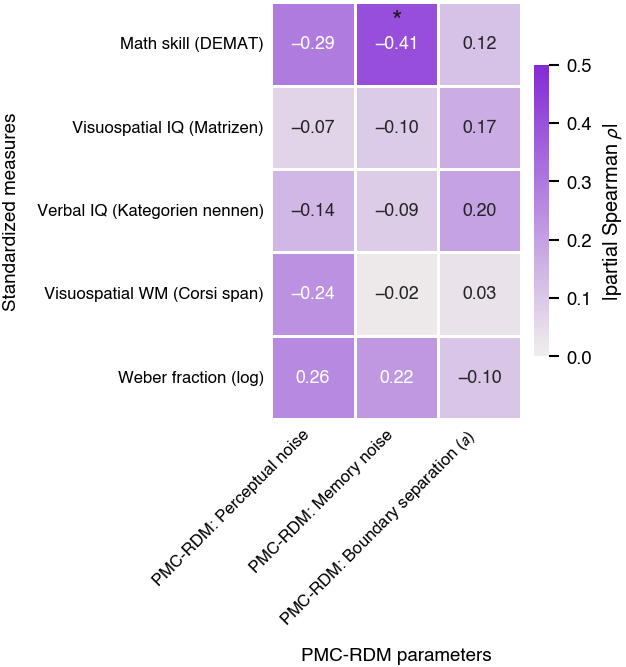

In [9]:
fig_c, ax_c = plt.subplots(figsize=(0.62 * len(rdm_vars) + 3.4,
                                    0.62 * len(cog_vars) + 1.6))
draw_matrix(ax_c, corr_c, pval_c_shown, vmax=0.5, cbar_label=CBAR_LABEL_M,
            cbar_shrink=0.7,
            row_labels=[pretty_cog[c] for c in cog_vars],
            col_labels=[pretty_mag[c] for c in rdm_vars])
ax_c.set_xlabel('PMC-RDM parameters', fontsize=9, labelpad=8)
ax_c.set_ylabel('Standardized measures', fontsize=9, labelpad=8)
fig_c.tight_layout()

for d in OUT_DIRS:
    fig_c.savefig(op.join(d, f'cognitive_x_pmcrdm_matrix{suffix_m}.pdf'))
print('written:', f'cognitive_x_pmcrdm_matrix{suffix_m}.pdf')

### The pairs, as a table

In [10]:
rows_c = []
for cv in cog_vars:
    for rv in rdm_vars:
        rows_c.append({'standardized measure': pretty_cog[cv],
                       'PMC-RDM parameter': pretty_mag[rv],
                       'rho': corr_c.loc[cv, rv], 'n': int(n_c.loc[cv, rv]),
                       'p_raw': pval_c.loc[cv, rv],
                       f'p_{MC_METHOD}': pval_c_corrected.loc[cv, rv]})

pd.DataFrame(rows_c).sort_values('p_raw').reset_index(drop=True).round(
    {'rho': 3, 'p_raw': 4, f'p_{MC_METHOD}': 4})

,standardized measure,PMC-RDM parameter,rho,n,p_raw,p_fdr_bh
0,Math skill (DEMAT),PMC-RDM: Memory noise,-0.406,66,0.0008,0.0117
1,Math skill (DEMAT),PMC-RDM: Perceptual noise,-0.294,66,0.0173,0.1300
2,Weber fraction (log),PMC-RDM: Perceptual noise,0.259,66,0.0370,0.1848
3,Visuospatial WM (Corsi span),PMC-RDM: Perceptual noise,-0.239,66,0.0552,0.2070
4,Weber fraction (log),PMC-RDM: Memory noise,0.222,66,0.0756,0.2269
5,Verbal IQ (Kategorien nennen),PMC-RDM: Boundary separation ($a$),0.196,66,0.1181,0.2952
6,Visuospatial IQ (Matrizen),PMC-RDM: Boundary separation ($a$),0.171,66,0.1742,0.3733
7,Verbal IQ (Kategorien nennen),PMC-RDM: Perceptual noise,-0.143,66,0.2575,0.4827
8,Math skill (DEMAT),PMC-RDM: Boundary separation ($a$),0.118,66,0.3480,0.5800
9,Weber fraction (log),PMC-RDM: Boundary separation ($a$),-0.105,66,0.4060,0.6023
